In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(compositions)
library(ecodist)
library(ggstatsplot)
library(patchwork)
library(cowplot)

── Attaching core tidyverse packages ─────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ───────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Welcome to compositions, a package for compositional data analysis.yverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conf

# File sorting============================================================================================================

In [2]:
# Read taxa data
taxa_tab <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/2025-11-11_vaginal_taxa_filtered.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
dim(taxa_tab)
head(taxa_tab)

[1]  65 175

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinobaculum massiliense,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.38593,0.00000,0.00000,0.00000
Aerococcus christensenii,0.00000,0,0.37028,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.00000,0.00000,0.23952,0.00000
Alloscardovia omnicolens,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00197,0.00000,0,1.74307,0,0.00000,0.00509,0.00000,0.71791
Anaerococcus hydrogenalis,0.00697,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00420,0,0.00319,0.00000,0.00000,0.00000
Anaerococcus lactolyticus,0.01879,0,0.00000,0,0.00000,0,0.00013,0,0,0.00035,⋯,0,0.00000,0.00062,0,0.02457,0,0.00000,0.00166,0.00000,0.00000
Anaerococcus prevotii,0.00000,0,0.00000,0,0.01267,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00989,0,0.00000,0.00000,0.00000,0.00000


In [3]:
colnames(taxa_tab)

[1] "FF00653546" "FF00653544" "FB02825409" "FF03817116" "FF01566745"
  [6] "FF02556135" "FF03818430" "FF01571976" "FF06040450" "FF06039085"
 [11] "FF06039956" "FF06039601" "FF06039627" "FF06039861" "FF03817982"
 [16] "FF05043974" "FF05044855" "FF05044200" "FF01570382" "FF06032885"
 [21] "FF06040007" "FF06579566" "FF06580410" "FF03815366" "FF01571067"
 [26] "FF01570828" "FF02015345" "FF02015010" "FF00653065" "FF00530476"
 [31] "FF02014263" "FF02015432" "FF02015296" "FF03817626" "FF05024757"
 [36] "FF05024748" "FF08440350" "FF04761480" "FF06040483" "FF06033048"
 [41] "FF06580418" "FF00657563" "FF00653167" "FF00657544" "FF00657476"
 [46] "FF06039868" "FF06039595" "FF06039831" "FF06039830" "FF05024953"
 [51] "FF05043336" "FF04023664" "FF02557868" "FF02556105" "FF02015815"
 [56] "FF06580399" "FF04761460" "FF01570782" "FF01570777" "FF05025296"
 [61] "FF01572419" "FF05025294" "FF05043003" "FF05025300" "FF05043036"
 [66] "FF02015546" "FF02739091" "FB02846091" "FF00620268" "FF00653071"
 [71] "FF00657923" "FF02014181" "FF03817636" "FF02555999" "FF00652411"
 [76] "FF00941094" "FF02014833" "FF00651927" "FF00530460" "FF02556090"
 [81] "FF00619356" "FF00531139" "FF00530247" "FF02740674" "FF00657534"
 [86] "FF00653507" "FF00652106" "FF02015011" "FF03816378" "FF03816924"
 [91] "FF00531215" "FF00530208" "FF00530163" "FF02014805" "FF00653014"
 [96] "FF00652988" "FF00531719" "FF01572430" "FF08440357" "FF04761496"
[101] "FF08440702" "FF05044402" "FF02740612" "FF06039064" "FF06743148"
[106] "FF04761509" "FF04761505" "FF06580438" "FF00652209" "FF03818217"
[111] "FF02014450" "FF02014344" "FF05044198" "FF00653280" "FF04761535"
[116] "FF02557890" "FF03817815" "FF03817183" "FF03817972" "FF03816858"
[121] "FF03818246" "FF02557245" "FF02015423" "FF05024823" "FF02015861"
[126] "FF02013773" "FF06580149" "FF00531053" "FF03818104" "FF03815388"
[131] "FF01570606" "FF03816408" "FF00531062" "FF01572330" "FF06743126"
[136] "FF06032176" "FF00657220" "FF00653474" "FF00531725" "FF00658016"
[141] "FF06039851" "FF00657251" "FF00531455" "FF03816395" "FF01572371"
[146] "FF01572506" "FF02014735" "FF02015041" "FF02740077" "FF08440262"
[151] "FF06581586" "FF06033016" "FF00531275" "FF04760553" "FF03816396"
[156] "FF00620158" "FF06032916" "FB02825218" "FF06743139" "FF00619973"
[161] "FF00530529" "FF01570524" "FB02846907" "FF04761515" "FF00657243"
[166] "FF05044395" "FF04760422" "FF00531801" "FF08440403" "FF08440398"
[171] "FF08440427" "FF03818480" "FF08440674" "FF08440393" "FF06039070"

In [4]:
taxa_tab[, 1]

[1]  0.00000  0.00000  0.00000  0.00697  0.01879  0.00000  0.00623  0.00000
 [9]  0.00000  0.01103  0.00000  0.00000  0.00000  0.00000  0.00052  0.13072
[17]  0.00957  0.02022  0.01255  0.00000  0.02617  0.00000  0.00000  0.01227
[25]  0.06033  0.10261  0.00000  0.00000  0.00000  0.00000  0.03241  0.00000
[33] 98.22154  0.00000  0.03729  0.70713  0.02794  0.00000  0.00000  0.00000
[41]  0.00000  0.04244  0.00738  0.05611  0.03749  0.00000  0.00000  0.00000
[49]  0.01996  0.13944  0.00000  0.01501  0.10168  0.00000  0.00000  0.00000
[57]  0.00000  0.00000  0.00000  0.00000  0.00805  0.00000  0.02838  0.00000
[65]  0.09977

In [5]:
tail(taxa_tab)

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ureaplasma parvum,0.00000,0.05158,0.00970,0.00000,0,0,0.03087,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.06229,0.00000,0.22328,0.93376,0.00000,0.00000,0.22960
Varibaculum cambriense,0.00805,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.01344,0.00000,0.02252,0.00000,0.00000,0.00000
Varibaculum massiliense,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.04088,0.00000,0.00000,0.00000,0.00000,0.00000,0.40982,0.00000,0.00000,0.01783
Veillonellaceae bacterium_DNF00626,0.02838,0.00000,0.90706,0.00000,0,0,0.01367,0,0.00000,0.00000,⋯,0.01054,0.00000,0.00000,0.00000,0.35534,0.00131,0.00000,0.00000,0.02001,0.00000
Winkia neuii,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.12902,0.00000,0.00000,0.00000,0.00000,0.00000
Other_taxa,0.09977,0.00000,0.80965,0.00544,0,0,0.06051,0,0.08047,0.01244,⋯,1.14737,2.24081,0.00757,0.02786,0.24871,0.77614,0.71443,0.10985,0.63242,0.03292


In [6]:
colSums(taxa_tab)

FF00653546 FF00653544 FB02825409 FF03817116 FF01566745 FF02556135 FF03818430 
       100        100        100        100        100        100        100 
FF01571976 FF06040450 FF06039085 FF06039956 FF06039601 FF06039627 FF06039861 
       100        100        100        100        100        100        100 
FF03817982 FF05043974 FF05044855 FF05044200 FF01570382 FF06032885 FF06040007 
       100        100        100        100        100        100        100 
FF06579566 FF06580410 FF03815366 FF01571067 FF01570828 FF02015345 FF02015010 
       100        100        100        100        100        100        100 
FF00653065 FF00530476 FF02014263 FF02015432 FF02015296 FF03817626 FF05024757 
       100        100        100        100        100        100        100 
FF05024748 FF08440350 FF04761480 FF06040483 FF06033048 FF06580418 FF00657563 
       100        100        100        100        100        100        100 
FF00653167 FF00657544 FF00657476 FF06039868 FF06039595 FF06039831 FF06039830 
       100        100        100        100        100        100        100 
FF05024953 FF05043336 FF04023664 FF02557868 FF02556105 FF02015815 FF06580399 
       100        100        100        100        100        100        100 
FF04761460 FF01570782 FF01570777 FF05025296 FF01572419 FF05025294 FF05043003 
       100        100        100        100        100        100        100 
FF05025300 FF05043036 FF02015546 FF02739091 FB02846091 FF00620268 FF00653071 
       100        100        100        100        100        100        100 
FF00657923 FF02014181 FF03817636 FF02555999 FF00652411 FF00941094 FF02014833 
       100        100        100        100        100        100        100 
FF00651927 FF00530460 FF02556090 FF00619356 FF00531139 FF00530247 FF02740674 
       100        100        100        100        100        100        100 
FF00657534 FF00653507 FF00652106 FF02015011 FF03816378 FF03816924 FF00531215 
       100        100        100        100        100        100        100 
FF00530208 FF00530163 FF02014805 FF00653014 FF00652988 FF00531719 FF01572430 
       100        100        100        100        100        100        100 
FF08440357 FF04761496 FF08440702 FF05044402 FF02740612 FF06039064 FF06743148 
       100        100        100        100        100        100        100 
FF04761509 FF04761505 FF06580438 FF00652209 FF03818217 FF02014450 FF02014344 
       100        100        100        100        100        100        100 
FF05044198 FF00653280 FF04761535 FF02557890 FF03817815 FF03817183 FF03817972 
       100        100        100        100        100        100        100 
FF03816858 FF03818246 FF02557245 FF02015423 FF05024823 FF02015861 FF02013773 
       100        100        100        100        100        100        100 
FF06580149 FF00531053 FF03818104 FF03815388 FF01570606 FF03816408 FF00531062 
       100        100        100        100        100        100        100 
FF01572330 FF06743126 FF06032176 FF00657220 FF00653474 FF00531725 FF00658016 
       100        100        100        100        100        100        100 
FF06039851 FF00657251 FF00531455 FF03816395 FF01572371 FF01572506 FF02014735 
       100        100        100        100        100        100        100 
FF02015041 FF02740077 FF08440262 FF06581586 FF06033016 FF00531275 FF04760553 
       100        100        100        100        100        100        100 
FF03816396 FF00620158 FF06032916 FB02825218 FF06743139 FF00619973 FF00530529 
       100        100        100        100        100        100        100 
FF01570524 FB02846907 FF04761515 FF00657243 FF05044395 FF04760422 FF00531801 
       100        100        100        100        100        100        100 
FF08440403 FF08440398 FF08440427 FF03818480 FF08440674 FF08440393 FF06039070 
       100        100        100        100        100        100        100

In [7]:
taxa <- as.data.frame(t(taxa_tab))
class(taxa)
head(taxa)

[1] "data.frame"

,Actinobaculum massiliense,Aerococcus christensenii,Alloscardovia omnicolens,Anaerococcus hydrogenalis,Anaerococcus lactolyticus,Anaerococcus prevotii,Anaerococcus sp_Marseille_P3915,Anaerococcus tetradius,Anaerococcus vaginalis,Atopobium deltae,⋯,Staphylococcus epidermidis,Streptococcus anginosus,Streptococcus SGB3665,Tissierellia bacterium_KA00581,Ureaplasma parvum,Varibaculum cambriense,Varibaculum massiliense,Veillonellaceae bacterium_DNF00626,Winkia neuii,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF00653546,0,0.00000,0,0.00697,0.01879,0.00000,0.00623,0.00000,0,0.01103,⋯,0,0,0,0.00000,0.00000,0.00805,0,0.02838,0,0.09977
FF00653544,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.05158,0.00000,0,0.00000,0,0.00000
FB02825409,0,0.37028,0,0.00000,0.00000,0.00000,0.00000,0.00477,0,0.00000,⋯,0,0,0,0.25771,0.00970,0.00000,0,0.90706,0,0.80965
FF03817116,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00544
FF01566745,0,0.00000,0,0.00000,0.00000,0.01267,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00000
FF02556135,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00000


In [8]:
# Read metadata
combined_meta_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-11_combined_tp1_filt_nulliparous.csv", header = TRUE, row.names = 1)
head(combined_meta_tp1)
dim(combined_meta_tp1)

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,4,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,3,⋯,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0,First pregnancy
5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,4,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy


[1]  52 566

In [9]:
# Select variables from metadata
variables_tp1 <- combined_meta_tp1 |> 
    select (Group, Studienummer, Q1_Personnummer, age_checked, Age_groups, excess_weight, Weight_before_C, BMI_prior, kit1.vaginal_sample.barcode, 
            Primipara, Q1_Smoking_checked, Q1_X64_Alcohol_during_pregnancy, Q1_X43.Antibiotics_last_3_months, high_stress_Q1, BMI_now_3_groups) 

In [10]:
dim(variables_tp1)
head(variables_tp1)

[1] 52 15

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.vaginal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF02014263,1,"Nej, jag har aldrig rökt",0,0,0,25
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,FF00653507,1,Rökt tidigare,0,0,0,> 25 Overweight
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF00653546,1,Feströkare,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF02557868,1,Rökt tidigare,0,0,1,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FB02825409,1,"Nej, jag har aldrig rökt",0,0,0,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657534,1,"Nej, jag har aldrig rökt",0,0,0,25


In [11]:
variables_tp1$Group <- as.factor(variables_tp1$Group)
variables_tp1$kit1.vaginal_sample.barcode <- as.character(variables_tp1$kit1.vaginal_sample.barcode)
variables_tp1$excess_weight <- as.factor(variables_tp1$excess_weight)
variables_tp1$Q1_X64_Alcohol_during_pregnancy <- as.factor(variables_tp1$Q1_X64_Alcohol_during_pregnancy)
variables_tp1$Q1_X43.Antibiotics_last_3_months <- as.factor(variables_tp1$Q1_X43.Antibiotics_last_3_months)
variables_tp1$high_stress_Q1 <- as.factor(variables_tp1$high_stress_Q1)

In [12]:
head(variables_tp1)

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.vaginal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<chr>,<fct>,<fct>,<fct>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF02014263,1,"Nej, jag har aldrig rökt",0,0,0,25
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,FF00653507,1,Rökt tidigare,0,0,0,> 25 Overweight
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF00653546,1,Feströkare,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF02557868,1,Rökt tidigare,0,0,1,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FB02825409,1,"Nej, jag har aldrig rökt",0,0,0,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657534,1,"Nej, jag har aldrig rökt",0,0,0,25


In [13]:
# Convert Q1_Smoking_ to categories 
smoking_category <- ifelse(variables_tp1$Q1_Smoking_checked == "Nej, jag har aldrig rökt", 0, 
                           ifelse(variables_tp1$Q1_Smoking_checked == "Rökt tidigare", 0,
                              ifelse(variables_tp1$Q1_Smoking_checked == "Feströkare", 1, NA)))

In [14]:
smoking_category

[1] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [15]:
# Replace column with smoking category
variables_tp1$Q1_Smoking_checked <- as.factor(smoking_category)
variables_tp1$Q1_Smoking_checked
head(variables_tp1)

[1] 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
[39] 0 0 0 0 0 0 0 0 0 0 0 0 0 0
Levels: 0 1

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.vaginal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF02014263,1,0,0,0,0,25
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,FF00653507,1,0,0,0,0,> 25 Overweight
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF00653546,1,1,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF02557868,1,0,0,0,1,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FB02825409,1,0,0,0,0,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657534,1,0,0,0,0,25


In [16]:
# Group bmi groups
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")
bmi_levels
variables_tp1$BMI_now_3_groups <- factor(variables_tp1$BMI_now_3_groups, levels = bmi_levels)
class(variables_tp1$BMI_now_3_groups)

[1] "< 18.5 Underweight"    "18.5-25 Normal weight" "> 25 Overweight"

[1] "factor"

In [17]:
head(variables_tp1)

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit1.vaginal_sample.barcode,Primipara,Q1_Smoking_checked,Q1_X64_Alcohol_during_pregnancy,Q1_X43.Antibiotics_last_3_months,high_stress_Q1,BMI_now_3_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF02014263,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,FF00653507,1,0,0,0,0,> 25 Overweight
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF00653546,1,1,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF02557868,1,0,0,0,1,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FB02825409,1,0,0,0,0,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657534,1,0,0,0,0,NA


In [18]:
# Create a table with relevant variables
adonis_tab <- variables_tp1 |> rename(Studynumber = Studienummer, Personalnumber = Q1_Personnummer, Age = age_checked, Sample_ID = kit1.vaginal_sample.barcode, 
                                      Smoking = Q1_Smoking_checked, Alcohol = Q1_X64_Alcohol_during_pregnancy, Antibiotics = Q1_X43.Antibiotics_last_3_months, 
                                      High_stress =  high_stress_Q1, BMI_groups = BMI_now_3_groups)
head(adonis_tab)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF02014263,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,FF00653507,1,0,0,0,0,> 25 Overweight
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF00653546,1,1,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF02557868,1,0,0,0,1,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FB02825409,1,0,0,0,0,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657534,1,0,0,0,0,NA


In [19]:
# Convert to character and clean whitespace
adonis_tab$Group <- trimws(as.character(adonis_tab$Group))
head(adonis_tab)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF02014263,1,0,0,0,0,NA
5301,First pregnancy,S1f862a6,P1f862a6,32,3,Yes,67,25,FF00653507,1,0,0,0,0,> 25 Overweight
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF00653546,1,1,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF02557868,1,0,0,0,1,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FB02825409,1,0,0,0,0,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657534,1,0,0,0,0,NA


In [20]:
# Rename groups for ease of reading plots
adonis_tab$Group <- ifelse(adonis_tab$Group == "First pregnancy", "Nulliparous", 
                                   ifelse(adonis_tab$Group == "Second pregnancy", "Primiparous", NA))

In [21]:
table(adonis_tab$Group)
#grep("BMI", names(combined_meta_tp1), value =TRUE )


Nulliparous Primiparous 
         26          26 

In [22]:
# Extract barcodes
barcodes <- adonis_tab$Sample_ID
length(barcodes)

[1] 52

In [23]:
taxa_tp1 <- taxa[, colnames(taxa) %in% barcodes]
dim(taxa_tp1)  

[1] 175   0

In [24]:
adonis_tab$Sample_ID
length(unique(rownames(taxa)))

[1] "FF02014263" "FF00653507" "FF00653546" "FF02557868" "FB02825409"
 [6] "FF00657534" "FF03817636" "FF02014805" "FF00651927" "FF00652411"
[11] "FF02015815" "FF02014833" "FF00657923" "FF00619356" "FF00653065"
[16] "FF00620268" "FF00653167" "FB02846091" "FF00653014" "FF02015432"
[21] "FF00653071" "FF00652106" "FF02014181" "FF00530208" "FF00657563"
[26] "FF02015345" "FF06039085" "FF00530247" "FF06580399" "FF06039601"
[31] "FF03817982" "FF05043036" "FF06039830" "FF05025300" "FF01570777"
[36] "FF05024757" "FF06040007" "FF05044855" "FF03816924" "FF05043003"
[41] "FF04023664" "FF06039627" "FF06039831" "FF01570782" "FF06039595"
[46] "FF04761460" "FF06032885" "FF06579566" "FF05024953" "FF05024748"
[51] "FF01566745" "FF01571067"

[1] 175

In [25]:
# Extraxt taxa TP1
taxa_kit1 <- taxa[rownames(taxa) %in% barcodes, ]
head(taxa_kit1)
dim(taxa_kit1)
#head (taxa)

,Actinobaculum massiliense,Aerococcus christensenii,Alloscardovia omnicolens,Anaerococcus hydrogenalis,Anaerococcus lactolyticus,Anaerococcus prevotii,Anaerococcus sp_Marseille_P3915,Anaerococcus tetradius,Anaerococcus vaginalis,Atopobium deltae,⋯,Staphylococcus epidermidis,Streptococcus anginosus,Streptococcus SGB3665,Tissierellia bacterium_KA00581,Ureaplasma parvum,Varibaculum cambriense,Varibaculum massiliense,Veillonellaceae bacterium_DNF00626,Winkia neuii,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF00653546,0,0.00000,0,0.00697,0.01879,0.00000,0.00623,0.00000,0,0.01103,⋯,0.00000,0,0,0.00000,0.00000,0.00805,0,0.02838,0,0.09977
FB02825409,0,0.37028,0,0.00000,0.00000,0.00000,0.00000,0.00477,0,0.00000,⋯,0.00000,0,0,0.25771,0.00970,0.00000,0,0.90706,0,0.80965
FF01566745,0,0.00000,0,0.00000,0.00000,0.01267,0.00000,0.00000,0,0.00000,⋯,0.00000,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00000
FF06039085,0,0.00000,0,0.00000,0.00035,0.00000,0.00000,0.00000,0,0.00000,⋯,0.00798,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.01244
FF06039601,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0.00000,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00001
FF06039627,0,4.20791,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0.00000,0,0,0.00000,0.09973,0.00000,0,1.07484,0,1.93883


[1] 52 65

In [26]:
# Order taxa according to meta data file, so they are in the same order
# Factor to convert rownames and adonis to deffine order

ordered_taxa <- taxa_kit1 |> arrange(factor(rownames(taxa_kit1), level = adonis_tab$Sample_ID))
#adonis_tab$Sample_ID
head(ordered_taxa)
head(adonis_tab$Sample_ID)
dim(adonis_tab)

,Actinobaculum massiliense,Aerococcus christensenii,Alloscardovia omnicolens,Anaerococcus hydrogenalis,Anaerococcus lactolyticus,Anaerococcus prevotii,Anaerococcus sp_Marseille_P3915,Anaerococcus tetradius,Anaerococcus vaginalis,Atopobium deltae,⋯,Staphylococcus epidermidis,Streptococcus anginosus,Streptococcus SGB3665,Tissierellia bacterium_KA00581,Ureaplasma parvum,Varibaculum cambriense,Varibaculum massiliense,Veillonellaceae bacterium_DNF00626,Winkia neuii,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF02014263,0,0.00000,0.00000,0.00000,0.00000,0,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.0000,0.00000,0,0.00000,0.00000,0.00000
FF00653507,0,1.96578,0.00000,0.00000,0.00000,0,0.00000,0.08090,0,0.02155,⋯,0,0,0,0.00000,0.0000,0.00000,0,0.17824,0.00000,0.12387
FF00653546,0,0.00000,0.00000,0.00697,0.01879,0,0.00623,0.00000,0,0.01103,⋯,0,0,0,0.00000,0.0000,0.00805,0,0.02838,0.00000,0.09977
FF02557868,0,0.00000,0.00000,0.00000,0.00000,0,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.0000,0.00000,0,0.00000,0.00000,0.00000
FB02825409,0,0.37028,0.00000,0.00000,0.00000,0,0.00000,0.00477,0,0.00000,⋯,0,0,0,0.25771,0.0097,0.00000,0,0.90706,0.00000,0.80965
FF00657534,0,0.78909,0.00207,0.00000,0.00299,0,0.00000,0.00000,0,0.00631,⋯,0,0,0,0.00000,0.0000,0.00996,0,0.01321,0.00463,0.40690


[1] "FF02014263" "FF00653507" "FF00653546" "FF02557868" "FB02825409"
[6] "FF00657534"

[1] 52 15

In [27]:
# Check if every ellement matches
all(rownames(ordered_taxa) == adonis_tab$Sample_ID)

[1] TRUE

In [28]:
# Find mismatches
which_mismatch <- which(rownames(ordered_taxa) != adonis_tab$Sample_ID)

# Show the differences
data.frame(
  taxa_row = rownames(ordered_taxa)[which_mismatch],
  metadata_id = adonis_tab$Sample_ID[which_mismatch]
)

taxa_row,metadata_id
<chr>,<chr>


# Jaccard==============================================================================================================

In [29]:
# pa to scale x (taxa?) to presence or absence (1/0) - purpose of Jaccard
# vegdist picks method
jaccard_tp1 <- ordered_taxa |>
    decostand(method = "pa") |>          
  vegdist(method = "jaccard")
head(jaccard_tp1)

[1] 0.9000000 0.8965517 0.6000000 0.8750000 0.8695652 0.8000000

In [30]:
jaccard_pcoa_tp1 <-wcmdscale(jaccard_tp1, eig = TRUE, add = TRUE)
jaccard_points_tp1 <- data.frame(jaccard_pcoa_tp1$points)
head(jaccard_points_tp1)

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,⋯,Dim41,Dim42,Dim43,Dim44,Dim45,Dim46,Dim47,Dim48,Dim49,Dim50
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF02014263,0.3805022,-0.04070533,-0.04199192,-0.17232355,0.01061924,-0.207585380,0.21784999,0.01307477,-0.016545896,0.06514716,⋯,-0.060619289,0.004880830,0.036085988,0.012310639,0.046048408,-0.029895879,0.013153135,0.0258423642,-0.0002579445,-0.029144241
FF00653507,-0.3897406,-0.17083759,-0.03194792,0.05719620,-0.08992006,-0.005167814,0.04806289,0.09150855,0.046631763,-0.02894133,⋯,-0.028517710,0.079819125,-0.005634650,-0.030156520,0.004745805,-0.027006616,-0.013772035,-0.0450431039,-0.0227910940,0.005179439
FF00653546,-0.2448941,0.30594559,-0.05864449,0.03026258,0.04499379,-0.206770879,-0.16163208,-0.06062419,-0.039135979,0.05773679,⋯,0.009333712,-0.016088719,0.021072261,-0.021528318,-0.015383395,0.018658961,-0.006322297,0.0124203283,0.0053952165,0.003124993
FF02557868,0.3403169,0.18418171,-0.23980576,0.02766607,-0.09198688,-0.035738068,0.14885635,0.03021636,0.302012557,0.10255116,⋯,0.003604084,0.004035893,0.005426499,-0.021503184,0.011476669,0.011470962,0.050799525,-0.0241885807,-0.0212481781,0.003237604
FB02825409,-0.2978195,-0.25412849,-0.11268381,0.08535372,-0.14734089,-0.009271075,0.14514021,0.10519453,0.001570787,-0.07663187,⋯,0.023290754,0.028083903,0.058433414,-0.055585534,0.007472890,0.009839791,-0.038129760,0.0106756945,0.0215749023,0.004304369
FF00657534,-0.3277200,-0.06257973,-0.05783900,0.06663908,-0.02292656,-0.121839011,-0.01327221,0.15408658,-0.041528965,0.05013376,⋯,-0.024980069,-0.065272693,-0.038271413,0.002387724,0.003177316,0.011896784,0.013849921,-0.0008037022,-0.0208186292,0.002308900


In [31]:
# Merge the points with metadata
jaccard_merged_tp1 <- jaccard_points_tp1 |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab, by = "Sample_ID")
head(jaccard_merged_tp1) 

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,FF02014263,0.3805022,-0.04070533,-0.04199192,-0.17232355,0.01061924,-0.207585380,0.21784999,0.01307477,-0.016545896,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,FF00653507,-0.3897406,-0.17083759,-0.03194792,0.05719620,-0.08992006,-0.005167814,0.04806289,0.09150855,0.046631763,⋯,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
3,FF00653546,-0.2448941,0.30594559,-0.05864449,0.03026258,0.04499379,-0.206770879,-0.16163208,-0.06062419,-0.039135979,⋯,3,No,64,22,1,1,0,0,1,18.5-25 Normal weight
4,FF02557868,0.3403169,0.18418171,-0.23980576,0.02766607,-0.09198688,-0.035738068,0.14885635,0.03021636,0.302012557,⋯,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight
5,FB02825409,-0.2978195,-0.25412849,-0.11268381,0.08535372,-0.14734089,-0.009271075,0.14514021,0.10519453,0.001570787,⋯,2,No,55,21,1,0,0,0,0,18.5-25 Normal weight
6,FF00657534,-0.3277200,-0.06257973,-0.05783900,0.06663908,-0.02292656,-0.121839011,-0.01327221,0.15408658,-0.041528965,⋯,4,No,67,24,1,0,0,0,0,NA


In [32]:
jaccard_dim1_tp1 <- round(jaccard_pcoa_tp1$eig[1]/sum(jaccard_pcoa_tp1$eig)*100, digits = 1)
jaccard_dim2_tp1 <- round(jaccard_pcoa_tp1$eig[1]/sum(jaccard_pcoa_tp1$eig)*100, digits = 1)
jaccard_dim1_tp1
jaccard_dim2_tp1

[1] 22.6

[1] 22.6

In [33]:
class(jaccard_merged_tp1$Group)
table(jaccard_merged_tp1$Group)
dim(jaccard_merged_tp1)

[1] "character"


Nulliparous Primiparous 
         26          26 

[1] 52 65

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


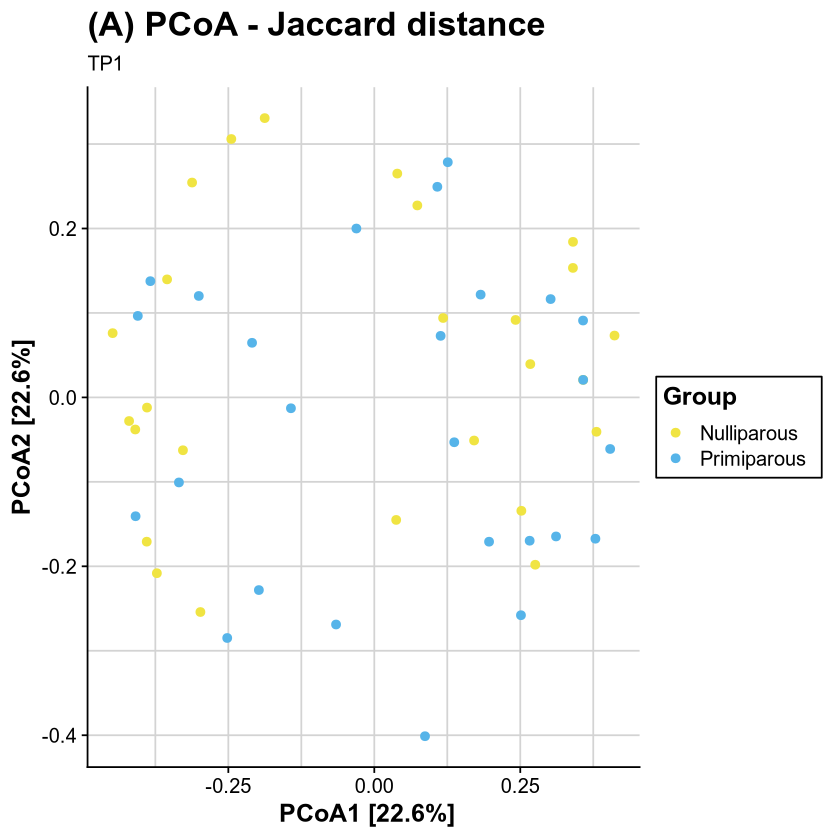

In [34]:
dye <- c("Nulliparous" = "#F0E442", "Primiparous" = "#56B4E9")

jaccard_plot <- jaccard_merged_tp1 |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", jaccard_dim2_tp1, "%]"),
        x = paste0(" PCoA1 [", jaccard_dim1_tp1, "%]"),
        title = "(A) PCoA - Jaccard distance",
        subtitle = "TP1"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
         axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
jaccard_plot

## PERMANOVA ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [35]:
set.seed(123)
adonis_Group <- adonis2(formula = jaccard_tp1 ~ Group, na.action = na.omit, data = adonis_tab)
# adonis_Group
# Rename "Model" to say Group, for better orientation
rownames(adonis_Group)[1] <- "Group"
adonis_Group
jaccard_pval <- adonis_Group[1, "Pr(>F)"]
jaccard_pval

jaccard_r2 <- adonis_Group[1, "R2"]
jaccard_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.4554958,0.03051378,1.573709,0.109
Residual,50,14.4720486,0.96948622,NA,NA
Total,51,14.9275444,1.00000000,NA,NA


[1] 0.109

[1] 0.03051378

In [36]:
adonis_Age <- adonis2(formula = jaccard_tp1 ~ Age , na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_Age)[1] <- "Age"
adonis_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.2320972,0.01554825,0.7896908,0.635
Residual,50,14.6954472,0.98445175,NA,NA
Total,51,14.9275444,1.00000000,NA,NA


In [37]:
adonis_Agegroup <- adonis2(formula = jaccard_tp1 ~ Age_groups , na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_Agegroup)[1] <- "Age_group"
adonis_Agegroup

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_group,1,0.2560701,0.0171542,0.8726803,0.568
Residual,50,14.6714743,0.9828458,NA,NA
Total,51,14.9275444,1.0000000,NA,NA


In [38]:
adonis_BMI <- adonis2(formula = jaccard_tp1 ~ BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_BMI)[1] <- "BMI_prior"
adonis_BMI

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_prior,1,0.3073294,0.02058807,1.051043,0.355
Residual,50,14.6202150,0.97941193,NA,NA
Total,51,14.9275444,1.00000000,NA,NA


In [39]:
adonis_bmigroups <- adonis2(formula = jaccard_tp1 ~ BMI_groups, na.action = na.omit, data = adonis_tab)
# Rename "Model" for better orientation
rownames(adonis_bmigroups)[1] <- "BMI_groups"
adonis_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,0.5522394,0.04218519,0.9469279,0.518
Residual,43,12.5385963,0.95781481,NA,NA
Total,45,13.0908357,1.00000000,NA,NA


# Aitchison=========================================================================================================

## Robust Aitchison

In [40]:
aitchison <- ordered_taxa |>
   as.matrix() |>
    vegdist(method = "robust.aitchison")
head(aitchison)
head(as.matrix(aitchison))

[1] 22.713827 13.039693  8.625541 30.721533 27.302812  8.685412

,1,2,3,4,5,6,7,8,9,10,⋯,43,44,45,46,47,48,49,50,51,52
1,0.000000,22.71383,13.039693,8.625541,30.72153,27.30281,8.685412,21.79806,5.547613,31.792697,⋯,18.42253,18.23899,20.92594,20.345766,15.01685,21.419191,30.175031,16.40648,21.81441,17.59647
2,22.713827,0.00000,10.722092,14.160299,14.00923,12.54035,15.257265,18.01890,17.402971,14.054765,⋯,16.97127,20.00993,22.71065,5.286211,24.96232,16.532115,8.390481,19.70940,19.20987,18.35930
3,13.039693,10.72209,0.000000,5.795688,19.43910,15.88347,4.688090,13.57111,8.589127,20.456721,⋯,12.25735,13.27354,15.93271,7.997797,15.87066,13.847412,17.485027,12.08328,13.75249,12.50946
4,8.625541,14.16030,5.795688,0.000000,23.68424,20.58540,4.371603,18.05782,3.512637,24.514711,⋯,14.87204,16.26521,19.47227,12.462105,16.76699,17.085440,21.917872,14.76769,18.52367,14.91654
5,30.721533,14.00923,19.439103,23.684237,0.00000,4.61530,23.435318,15.63150,25.855225,2.041789,⋯,15.37372,18.98924,21.29494,11.977936,26.00952,12.548176,9.651255,20.03008,19.02657,17.21796
6,27.302812,12.54035,15.883472,20.585404,4.61530,0.00000,19.721929,11.25603,22.718775,6.449642,⋯,12.02090,14.93389,16.99213,9.176126,22.02298,9.422437,9.965353,15.90711,14.45757,13.66495


In [41]:
# Convert to matrix and re-assign proper row and column names since they did not transfer properly
aitchison_matrix <- as.matrix(aitchison)
rownames(aitchison_matrix) <- rownames(ordered_taxa)
colnames(aitchison_matrix) <- rownames(ordered_taxa)
head(aitchison_matrix)

,FF02014263,FF00653507,FF00653546,FF02557868,FB02825409,FF00657534,FF03817636,FF02014805,FF00651927,FF00652411,⋯,FF06039831,FF01570782,FF06039595,FF04761460,FF06032885,FF06579566,FF05024953,FF05024748,FF01566745,FF01571067
FF02014263,0.000000,22.71383,13.039693,8.625541,30.72153,27.30281,8.685412,21.79806,5.547613,31.792697,⋯,18.42253,18.23899,20.92594,20.345766,15.01685,21.419191,30.175031,16.40648,21.81441,17.59647
FF00653507,22.713827,0.00000,10.722092,14.160299,14.00923,12.54035,15.257265,18.01890,17.402971,14.054765,⋯,16.97127,20.00993,22.71065,5.286211,24.96232,16.532115,8.390481,19.70940,19.20987,18.35930
FF00653546,13.039693,10.72209,0.000000,5.795688,19.43910,15.88347,4.688090,13.57111,8.589127,20.456721,⋯,12.25735,13.27354,15.93271,7.997797,15.87066,13.847412,17.485027,12.08328,13.75249,12.50946
FF02557868,8.625541,14.16030,5.795688,0.000000,23.68424,20.58540,4.371603,18.05782,3.512637,24.514711,⋯,14.87204,16.26521,19.47227,12.462105,16.76699,17.085440,21.917872,14.76769,18.52367,14.91654
FB02825409,30.721533,14.00923,19.439103,23.684237,0.00000,4.61530,23.435318,15.63150,25.855225,2.041789,⋯,15.37372,18.98924,21.29494,11.977936,26.00952,12.548176,9.651255,20.03008,19.02657,17.21796
FF00657534,27.302812,12.54035,15.883472,20.585404,4.61530,0.00000,19.721929,11.25603,22.718775,6.449642,⋯,12.02090,14.93389,16.99213,9.176126,22.02298,9.422437,9.965353,15.90711,14.45757,13.66495


In [42]:
aitchison_pcoa <- wcmdscale(aitchison_matrix, eig = TRUE)
aitchison_points <- data.frame(aitchison_pcoa$points)
head(aitchison_points)
aitchison_merged <- aitchison_points |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab, by = "Sample_ID")
head(aitchison_merged)

,Dim1,Dim2,Dim3
,<dbl>,<dbl>,<dbl>
FF02014263,14.077416,-7.855516,4.2462016
FF00653507,-6.761985,-8.337663,-4.7762641
FF00653546,3.103699,-5.020620,-2.2016268
FF02557868,6.284620,-8.900787,0.6994141
FB02825409,-14.925937,1.637485,0.7105176
FF00657534,-10.616806,2.792286,-0.4721978


,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,FF02014263,14.077416,-7.855516,4.2462016,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,NA
2,FF00653507,-6.761985,-8.337663,-4.7762641,Nulliparous,S1f862a6,P1f862a6,32,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
3,FF00653546,3.103699,-5.020620,-2.2016268,Nulliparous,S1f95844,P1f95844,30,3,No,64,22,1,1,0,0,1,18.5-25 Normal weight
4,FF02557868,6.284620,-8.900787,0.6994141,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight
5,FB02825409,-14.925937,1.637485,0.7105176,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,1,0,0,0,0,18.5-25 Normal weight
6,FF00657534,-10.616806,2.792286,-0.4721978,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,1,0,0,0,0,NA


In [43]:
#head(aitchison_pcoa)

In [44]:
nrow(ordered_taxa)
length(aitchison_pcoa$eig)
eig_vals <- aitchison_pcoa$eig
# How many non-zero eigenvalues?
sum(eig_vals > 1e-6)  # Threshold to count "non-zero" dimensions

# Show all eigenvalues
eig_vals

[1] 52

[1] 3

[1] 3

[1] 4441.867 1960.475 1068.629

In [45]:
# Save the eigenvalues, add percentages for plot
aitchison_dim1 <- round(aitchison_pcoa$eig[1]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim2 <- round(aitchison_pcoa$eig[2]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim1
aitchison_dim2

[1] 59.5

[1] 26.2

In [46]:
aitchison_dim3 <- round(aitchison_pcoa$eig[3]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim4 <- round(aitchison_pcoa$eig[4]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim3
aitchison_dim4

[1] 14.3

[1] NA

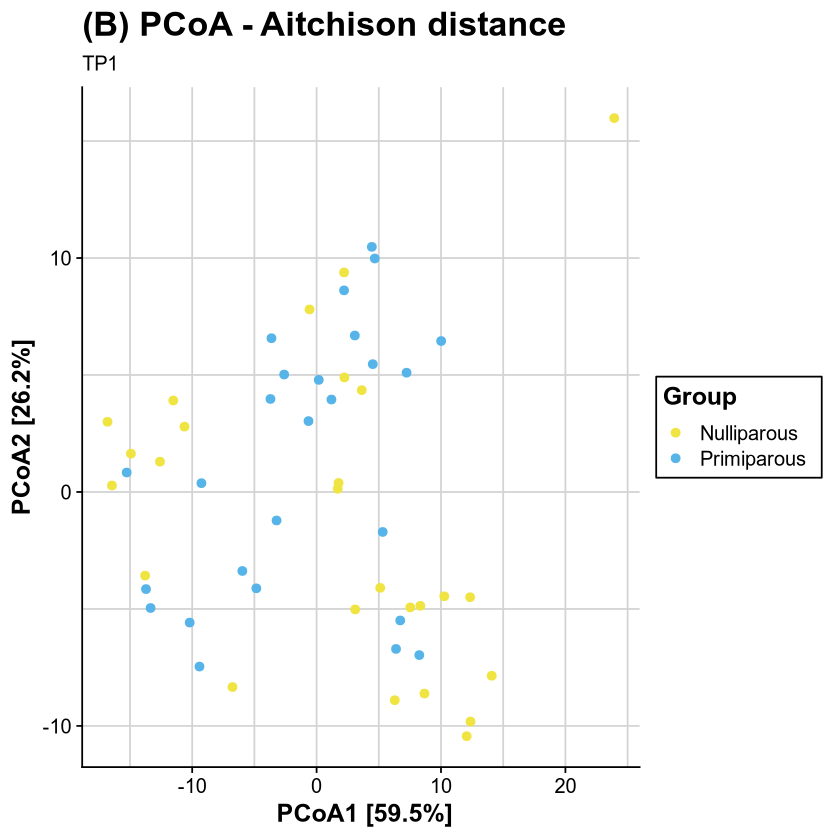

In [47]:
aitchison_plot <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", aitchison_dim2, "%]"),
        x = paste0(" PCoA1 [", aitchison_dim1, "%]"),
        title = "(B) PCoA - Aitchison distance",
        subtitle = "TP1"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    #background_grid() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
    
aitchison_plot

## PERMANOVA ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [48]:
set.seed(123)
adonis_ait_Group <- adonis2(formula = aitchison  ~ Group, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_Group)[1] <- "Group"
adonis_ait_Group
aitchison_pval <- adonis_ait_Group[1, "Pr(>F)"]
aitchison_pval


aitchison_r2 <- adonis_ait_Group[1, "R2"]
aitchison_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,149.8026,0.02005129,1.023079,0.366
Residual,50,7321.1687,0.97994871,NA,NA
Total,51,7470.9714,1.00000000,NA,NA


[1] 0.366

[1] 0.02005129

In [49]:
adonis_ait_Age <- adonis2(formula = aitchison  ~ Age, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_Age)[1] <- "Age"
adonis_ait_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,65.45042,0.008760631,0.4419029,0.707
Residual,50,7405.52097,0.991239369,NA,NA
Total,51,7470.97139,1.000000000,NA,NA


In [50]:
adonis_ait_bmigroups <- adonis2(formula = aitchison ~ BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_bmigroups)[1] <- "BMI_groups"
adonis_ait_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,171.734,0.02738844,0.6054334,0.679
Residual,43,6098.575,0.97261156,NA,NA
Total,45,6270.309,1.00000000,NA,NA


In [51]:
adonis_ait_group_bmigroups <- adonis2(formula = aitchison ~ Group + BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_ait_group_bmigroups)[1] <- "Group_bmi_groups"
adonis_ait_group_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi_groups,3,389.0627,0.06204841,0.9261434,0.458
Residual,42,5881.2466,0.93795159,NA,NA
Total,45,6270.3094,1.00000000,NA,NA


# Bray curtis=======================================================================================================================================

In [52]:
bray_curt_dist <- vegdist(ordered_taxa, method = "bray")
head(as.matrix(bray_curt_dist))

,FF02014263,FF00653507,FF00653546,FF02557868,FB02825409,FF00657534,FF03817636,FF02014805,FF00651927,FF00652411,⋯,FF06039831,FF01570782,FF06039595,FF04761460,FF06032885,FF06579566,FF05024953,FF05024748,FF01566745,FF01571067
FF02014263,0.0000000,0.9998140,0.0173456,0.0151748,0.9995570,0.9994219,0.0093810,0.9994932,0.0042852,0.9995559,⋯,0.9994613,0.9996486,0.9995434,0.9998435,0.9994199,0.9995610,0.9998435,0.9990142,0.9986404,0.9997175
FF00653507,0.9998140,0.0000000,0.9940946,0.9999705,0.2050784,0.7158796,0.9998936,0.9805013,0.9971329,0.3753724,⋯,0.9929605,0.9999553,0.9993875,0.0870539,0.9999176,0.9922199,0.0546493,0.9983714,0.9900070,0.9974466
FF00653546,0.0173456,0.9940946,0.0000000,0.0106053,0.9960977,0.9948579,0.0106069,0.9984571,0.0151970,0.9939061,⋯,0.9904323,0.9995430,0.9990265,0.9953713,0.9923486,0.9976033,0.9989200,0.9904788,0.9901826,0.9984220
FF02557868,0.0151748,0.9999705,0.0106053,0.0000000,0.9998880,0.9997529,0.0060082,0.9998242,0.0139862,0.9998869,⋯,0.9901972,0.9998231,0.9998744,1.0000000,0.9899072,0.9998920,1.0000000,0.9855869,0.9893763,0.9998920
FB02825409,0.9995570,0.2050784,0.9960977,0.9998880,0.0000000,0.6984858,0.9998896,0.9594159,0.9964604,0.2349944,⋯,0.9661898,0.9790366,0.9784688,0.2149698,0.9999136,0.9698841,0.1785160,0.9776217,0.9691738,0.9765319
FF00657534,0.9994219,0.7158796,0.9948579,0.9997529,0.6984858,0.0000000,0.9997545,0.2688194,0.9963253,0.7308602,⋯,0.7228883,0.2882723,0.2877558,0.7558785,0.9997785,0.2792817,0.7262320,0.5773277,0.6476884,0.2858106


In [53]:
bray_curt_pcoa <- pco(bray_curt_dist)
#head(bray_curt_pcoa)

In [54]:
bray_vect <- bray_curt_pcoa$vectors
bray_curt_merged <- bray_vect |>
    rownames_to_column(var= "Sample_ID") |>
    left_join(adonis_tab, by = "Sample_ID")
head(bray_curt_merged)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>
1,FF02014263,0.5415566,-0.2472424,-0.03546246,0.02345169,0.002049349,-0.0030782769,-0.014171646,0.010651174,0.008991928,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,FF00653507,-0.4519875,-0.3115796,-0.01921749,0.08024164,-0.029784042,-0.0112657702,-0.062186253,-0.029128224,0.035284153,⋯,3,Yes,67,25,1,0,0,0,0,> 25 Overweight
3,FF00653546,0.5375264,-0.2432133,-0.02871255,0.02679426,0.002939158,-0.0026494669,-0.005643809,0.006813919,-0.006717715,⋯,3,No,64,22,1,1,0,0,1,18.5-25 Normal weight
4,FF02557868,0.5412980,-0.2419282,-0.02279789,0.02889384,0.001866709,0.0004087788,-0.011152872,-0.001046209,-0.005448664,⋯,3,No,56,21,1,0,0,0,1,18.5-25 Normal weight
5,FB02825409,-0.4470402,-0.2822146,-0.02292967,0.04744300,0.072255154,-0.0069941268,0.074666914,0.051350572,0.001095369,⋯,2,No,55,21,1,0,0,0,0,18.5-25 Normal weight
6,FF00657534,-0.2343204,0.3474153,-0.27692135,0.07750430,0.042259403,0.0389884440,0.050052087,-0.018581097,0.107075106,⋯,4,No,67,24,1,0,0,0,0,NA


In [55]:
bray_curt_df <- data.frame(Sample_ID = bray_curt_merged[,1],
                          Group = bray_curt_merged$Group,
                           pcoa1 = bray_curt_merged[,2],
                           pcoa2 = bray_curt_merged[,3],
                           pcoa3 = bray_curt_merged[,4]
                          )
head(bray_curt_df)

,Sample_ID,Group,pcoa1,pcoa2,pcoa3
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,FF02014263,Nulliparous,0.5415566,-0.2472424,-0.03546246
2,FF00653507,Nulliparous,-0.4519875,-0.3115796,-0.01921749
3,FF00653546,Nulliparous,0.5375264,-0.2432133,-0.02871255
4,FF02557868,Nulliparous,0.5412980,-0.2419282,-0.02279789
5,FB02825409,Nulliparous,-0.4470402,-0.2822146,-0.02292967
6,FF00657534,Nulliparous,-0.2343204,0.3474153,-0.27692135


In [56]:
# Save the eigenvalues, add percentages for plot
bray_dim1 <- round(bray_curt_pcoa$values[1]/sum(bray_curt_pcoa$values)*100, digits = 1)
bray_dim2 <- round(bray_curt_pcoa$values[2]/sum(bray_curt_pcoa$values)*100,  digits = 1)
bray_dim2
bray_dim1

[1] 32.3

[1] 39.5

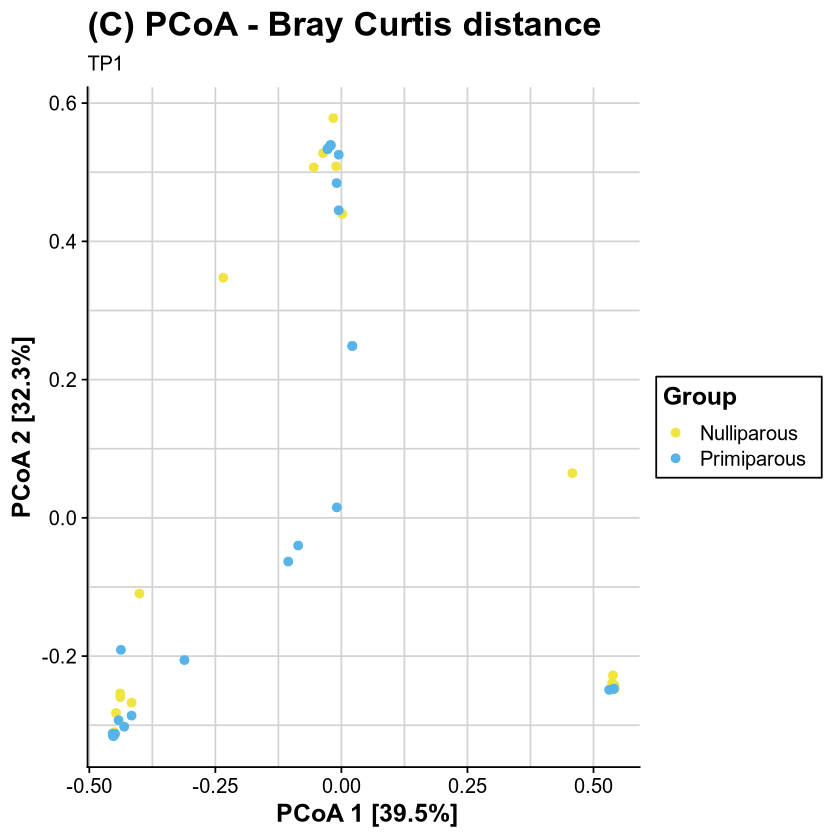

In [57]:
bray_plot <- bray_curt_df |>
    ggplot(aes(x = pcoa1, y = pcoa2, color = Group)) +
    geom_point() +
    labs(
        x = paste0(" PCoA 1 [", bray_dim1, "%]"),
        y = paste0("PCoA 2 [", bray_dim2, "%]"),
        title = "(C) PCoA - Bray Curtis distance",
        subtitle = "TP1"
    ) +
    scale_color_manual(values = dye) +
    theme_half_open() +
    theme( 
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
     )

bray_plot

## PERMANOVA ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [58]:
set.seed(123)
adonis_bray_Group <- adonis2(formula = bray_curt_dist ~ Group, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_Group)[1] <- "Group"
adonis_bray_Group
bray_pval <- adonis_bray_Group[1, "Pr(>F)"]
bray_pval


bray_r2 <- adonis_bray_Group[1, "R2"]
bray_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,1.000189,0.05393637,2.850568,0.049
Residual,50,17.543680,0.94606363,NA,NA
Total,51,18.543869,1.00000000,NA,NA


[1] 0.049

[1] 0.05393637

In [59]:
adonis_bray_Age <- adonis2(formula = bray_curt_dist ~ Age, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_Age)[1] <- "Age"
adonis_bray_Age
#head(adonis_tab)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.1048572,0.005654548,0.2843352,0.891
Residual,50,18.4390116,0.994345452,NA,NA
Total,51,18.5438688,1.000000000,NA,NA


In [60]:
adonis_bray_bmigroups <- adonis2(formula = bray_curt_dist ~ BMI_groups, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_bmigroups)[1] <- "BMI_groups"
adonis_bray_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,0.7015178,0.04212958,0.9456248,0.486
Residual,43,15.9499125,0.95787042,NA,NA
Total,45,16.6514303,1.00000000,NA,NA


In [61]:
adonis_bray_group_bmi <- adonis2(formula = bray_curt_dist ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_group_bmi)[1] <- "Group_bmi"
adonis_bray_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi,2,1.258905,0.06788796,1.784394,0.098
Residual,49,17.284963,0.93211204,NA,NA
Total,51,18.543869,1.00000000,NA,NA


In [62]:
adonis_bray_age_bmi <- adonis2(formula = bray_curt_dist ~ Age + BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_age_bmi)[1] <- "Age_bmi"
adonis_bray_age_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_bmi,2,0.4921785,0.02654131,0.6679914,0.699
Residual,49,18.0516903,0.97345869,NA,NA
Total,51,18.5438688,1.00000000,NA,NA


In [63]:
adonis_bray_agegroup_bmi <- adonis2(formula = bray_curt_dist ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_agegroup_bmi)[1] <- "AgeGroups_bmi"
adonis_bray_agegroup_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_bmi,2,0.550902,0.02970804,0.750132,0.63
Residual,49,17.992967,0.97029196,NA,NA
Total,51,18.543869,1.00000000,NA,NA


In [64]:
adonis_bray_agegroup_weight <- adonis2(formula = bray_curt_dist ~ Age_groups + Weight_before_C, na.action = na.omit, data = adonis_tab)
rownames(adonis_bray_agegroup_weight)[1] <- "AgeGroups_weightBefore"
adonis_bray_agegroup_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroups_weightBefore,2,0.5590369,0.03014672,0.761553,0.614
Residual,49,17.9848319,0.96985328,NA,NA
Total,51,18.5438688,1.00000000,NA,NA


# Combined plots ------------------------------------------------------------------------------------------

In [65]:
class(jaccard_plot) 

[1] "ggplot2::ggplot" "ggplot"          "ggplot2::gg"     "S7_object"      
[5] "gg"

In [77]:
# Extract legend from bray plot
legend_bray <- get_legend(bray_plot)

In [78]:
# remove legends so only one remains
plot_jaccard_nl <- jaccard_plot +  guides(fill = "none", color = "none") 
plot_aitch_nl <- aitchison_plot +  guides(fill = "none", color = "none") 
plot_bray_nl <- bray_plot +  guides(fill = "none", color = "none") 

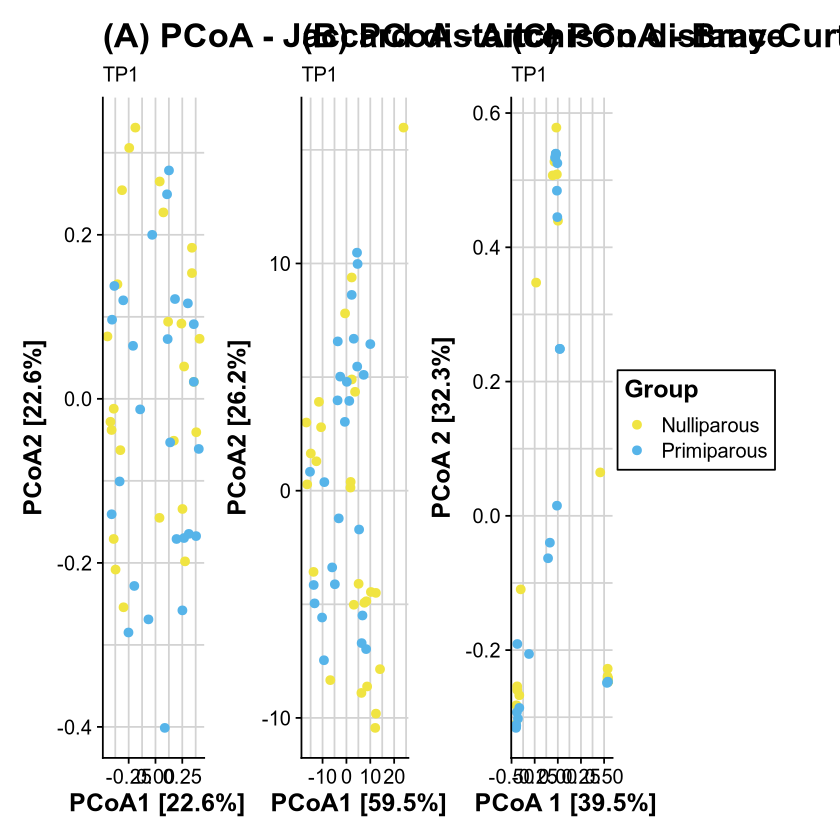

In [79]:
combined_plot <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, nrow =1) 

combined_plot_legend <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, legend_bray, nrow =1) 


final_plot <- ggdraw(combined_plot_legend) +
  theme_half_open() +
  background_grid() +
  theme(
    axis.text.x = element_blank(),
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )
final_plot


In [83]:
ggsave(file = paste0(Sys.Date(), "_vag_beta_tp1.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = final_plot, width = 19, height = 8)

# Exporting data===============================================================================

In [69]:
#write.csv(jaccard_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_jaccard_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(aitchison_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_aitchison_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(bray_curt_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
                                      #  "_bray_curt_df_tp1", ".csv"), row.names = FALSE)

# Bar plots -----------------------------------------------------------------------------

In [70]:
bar_df <- data.frame(
    Distance_metrics = c("Jaccard", "Aitchison", "Bray_Curtis"),
    Pvalue = c(jaccard_pval, aitchison_pval, bray_pval),
       R2 = c(jaccard_r2, aitchison_r2, bray_r2)
)
bar_df

Distance_metrics,Pvalue,R2
<chr>,<dbl>,<dbl>
Jaccard,0.109,0.03051378
Aitchison,0.366,0.02005129
Bray_Curtis,0.049,0.05393637


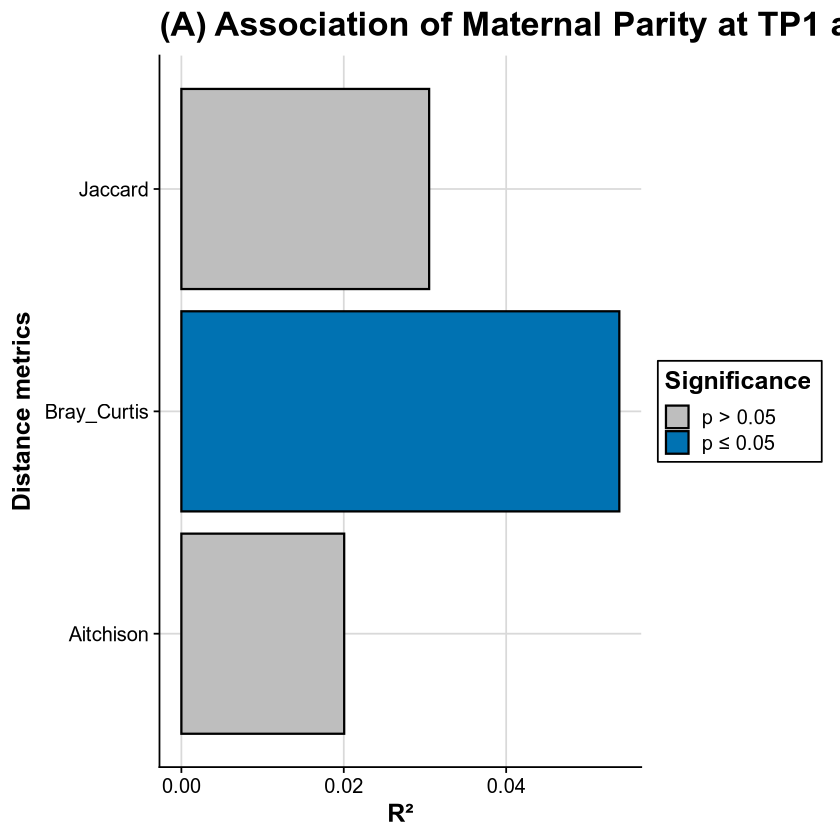

In [75]:
# Create column specifying p value greater or lesser
bar_df$Significance <- factor(ifelse(bar_df$Pvalue < 0.05, "p ≤ 0.05", "p > 0.05"))
dye_pval <- c("p ≤ 0.05" = "#0072B2", "p > 0.05" = "grey") # color vector 

#names(dye_pval) <- bar_df$Distance

bar_plot <- bar_df |>
    ggplot(aes(x = R2, y = Distance_metrics, fill = Significance)) +
    geom_col(colour = "black") +
    scale_fill_manual(values = dye_pval) +
    labs(title = "(A) Association of Maternal Parity at TP1 across Distance Metrics for the Vaginal Microbiome",
        x = "R²",
        y = "Distance metrics") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")) +
    background_grid()

bar_plot

In [82]:
ggsave(file = paste0(Sys.Date(), "_vag_beta_tp1_bar.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
       plot = bar_plot, width = 14, height = 8)

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'p ≤ 0.05' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)”
